# Phase 1: Domain Research + Dataset + EDA + Baseline
## Drug Molecule Property Prediction — ogbg-molhiv (HIV Activity)

**Date:** 2026-04-06 | **Researcher:** Anthony Rodrigues | **Primary Metric:** ROC-AUC

---

### Domain Research

Before selecting a dataset or writing any code, I searched for:
- "best dataset molecular property prediction ML 2024 2025 benchmark"
- "MoleculeNet vs TDC vs OGB comparison most used"
- "ogbg-molhiv leaderboard best model 2024 2025"

**Key findings from research:**

1. **Three dominant benchmarks exist:** MoleculeNet (Wu et al., 2018, 1800+ citations), TDC/ADMET (Harvard, 22 tasks), and OGB (Stanford, graph-focused leaderboard)
2. **MoleculeNet and TDC share similar flaws** — data collection biases, small datasets (ESOL=1,128, FreeSolv=642)
3. **OGB provides the most rigorous evaluation** — fixed scaffold splits, public leaderboard, standardized evaluation
4. **SOTA on ogbg-molhiv: ROC-AUC ~0.848** (Multi-RF Fusion + Multi-GNN) — our target to compare against
5. **Geometric GNNs and multi-modal approaches** lead current benchmarks

### Dataset Selection Rationale

| Dataset | Size | Task | Leaderboard | Why chosen/rejected |
|---------|------|------|-------------|---------------------|
| ESOL | 1,128 | Regression | No | Too small for credible ML |
| FreeSolv | 642 | Regression | No | Even smaller |
| Lipophilicity | 4,200 | Regression | No | Medium, no leaderboard |
| AqSolDB (TDC) | 9,982 | Regression | TDC | Decent size, growing |
| BBBP | 2,050 | Classification | No | Small |
| **ogbg-molhiv** | **41,127** | **Classification** | **OGB (20+ entries)** | **Chosen: largest, best benchmarked, impactful** |

**ogbg-molhiv** wins because: (1) 41K molecules is real-world scale, (2) established OGB leaderboard with 20+ entries, (3) HIV drug activity prediction has clear real-world impact, (4) binary classification makes results easy to communicate.

### References
- [Wu et al. (2018)](https://pmc.ncbi.nlm.nih.gov/articles/PMC5868307/) — MoleculeNet benchmark
- [Hu et al. (2020)](https://arxiv.org/abs/2005.00687) — Open Graph Benchmark
- [OGB Leaderboard](https://ogb.stanford.edu/docs/leader_graphprop/) — SOTA: 0.8476 ROC-AUC
- [Xiong et al. (2020)](https://pubs.acs.org/doi/10.1021/acs.jmedchem.9b00959) — AttentiveFP for molecular property prediction

In [1]:
import sys, os, json, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score, accuracy_score
from sklearn.preprocessing import StandardScaler
import xgboost as xgb

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='husl', font_scale=1.1)

BASE_DIR = Path(os.getcwd()).parent if 'notebooks' in os.getcwd() else Path(os.getcwd())
DATA_DIR = BASE_DIR / 'data'
RESULTS_DIR = BASE_DIR / 'results'
RESULTS_DIR.mkdir(exist_ok=True)
(DATA_DIR / 'processed').mkdir(parents=True, exist_ok=True)

sys.path.insert(0, str(BASE_DIR / 'src'))
from data_pipeline import download_ogbg_molhiv, build_feature_matrix

## 1. Download ogbg-molhiv (41,127 molecules, scaffold split)

In [2]:
df = download_ogbg_molhiv()
print(f'Total molecules: {len(df):,}')
print(f'\nSplit distribution:')
print(df['split'].value_counts().to_string())
print(f'\nTarget distribution (HIV active):')
print(df['hiv_active'].value_counts().to_string())
print(f'\nPositive rate: {df["hiv_active"].mean():.4f} ({df["hiv_active"].sum():,} / {len(df):,})')

Loading necessary files...
This might take a while.
Processing graphs...


  0%|          | 0/41127 [00:00<?, ?it/s]

 87%|████████▋ | 35909/41127 [00:00<00:00, 358982.50it/s]

100%|██████████| 41127/41127 [00:00<00:00, 357269.04it/s]

Saving...


Total molecules: 41,127

Split distribution:
split
train    32901
test      4113
val       4113

Target distribution (HIV active):
hiv_active
0    39684
1     1443

Positive rate: 0.0351 (1,443 / 41,127)


## 2. Compute Molecular Features (Lipinski + Morgan FP)

Computing 14 Lipinski/ADMET descriptors + 1024-bit Morgan fingerprints for all 41K molecules.

In [3]:
t0 = time.time()
df_feat = build_feature_matrix(df, fp_radius=2, fp_bits=1024)
elapsed = time.time() - t0
print(f'Feature matrix: {df_feat.shape} ({elapsed:.1f}s)')
print(f'Valid molecules: {len(df_feat):,} / {len(df):,} ({100*len(df_feat)/len(df):.1f}%)')
df_feat.to_csv(DATA_DIR / 'processed' / 'molhiv_features.csv', index=False)
print(f'Saved to data/processed/molhiv_features.csv')

[21:34:43] DEPRECATION WARNING: please use MorganGenerator
[21:34:43] DEPRECATION WARNING: please use MorganGenerator
[21:34:43] DEPRECATION WARNING: please use MorganGenerator
[21:34:43] DEPRECATION WARNING: please use MorganGenerator
[21:34:43] DEPRECATION WARNING: please use MorganGenerator
[21:34:43] DEPRECATION WARNING: please use MorganGenerator
[21:34:43] DEPRECATION WARNING: please use MorganGenerator
[21:34:43] DEPRECATION WARNING: please use MorganGenerator
[21:34:43] DEPRECATION WARNING: please use MorganGenerator
[21:34:43] DEPRECATION WARNING: please use MorganGenerator
[21:34:43] DEPRECATION WARNING: please use MorganGenerator
[21:34:43] DEPRECATION WARNING: please use MorganGenerator
[21:34:43] DEPRECATION WARNING: please use MorganGenerator
[21:34:43] DEPRECATION WARNING: please use MorganGenerator
[21:34:43] DEPRECATION WARNING: please use MorganGenerator
[21:34:43] DEPRECATION WARNING: please use MorganGenerator
[21:34:43] DEPRECATION WARNING: please use MorganGenerat

[21:34:44] DEPRECATION WARNING: please use MorganGenerator
[21:34:44] DEPRECATION WARNING: please use MorganGenerator
[21:34:44] DEPRECATION WARNING: please use MorganGenerator
[21:34:44] DEPRECATION WARNING: please use MorganGenerator
[21:34:44] DEPRECATION WARNING: please use MorganGenerator
[21:34:44] DEPRECATION WARNING: please use MorganGenerator
[21:34:44] DEPRECATION WARNING: please use MorganGenerator
[21:34:44] DEPRECATION WARNING: please use MorganGenerator
[21:34:44] DEPRECATION WARNING: please use MorganGenerator
[21:34:44] DEPRECATION WARNING: please use MorganGenerator
[21:34:44] DEPRECATION WARNING: please use MorganGenerator
[21:34:44] DEPRECATION WARNING: please use MorganGenerator
[21:34:44] DEPRECATION WARNING: please use MorganGenerator
[21:34:44] DEPRECATION WARNING: please use MorganGenerator
[21:34:44] DEPRECATION WARNING: please use MorganGenerator
[21:34:44] DEPRECATION WARNING: please use MorganGenerator
[21:34:44] DEPRECATION WARNING: please use MorganGenerat

[21:34:44] DEPRECATION WARNING: please use MorganGenerator
[21:34:44] DEPRECATION WARNING: please use MorganGenerator
[21:34:44] DEPRECATION WARNING: please use MorganGenerator
[21:34:44] DEPRECATION WARNING: please use MorganGenerator
[21:34:44] DEPRECATION WARNING: please use MorganGenerator
[21:34:44] DEPRECATION WARNING: please use MorganGenerator
[21:34:44] DEPRECATION WARNING: please use MorganGenerator
[21:34:44] DEPRECATION WARNING: please use MorganGenerator
[21:34:44] DEPRECATION WARNING: please use MorganGenerator
[21:34:44] DEPRECATION WARNING: please use MorganGenerator
[21:34:44] DEPRECATION WARNING: please use MorganGenerator
[21:34:44] DEPRECATION WARNING: please use MorganGenerator
[21:34:44] DEPRECATION WARNING: please use MorganGenerator
[21:34:44] DEPRECATION WARNING: please use MorganGenerator
[21:34:44] DEPRECATION WARNING: please use MorganGenerator
[21:34:44] DEPRECATION WARNING: please use MorganGenerator
[21:34:44] DEPRECATION WARNING: please use MorganGenerat

[21:34:44] DEPRECATION WARNING: please use MorganGenerator
[21:34:44] DEPRECATION WARNING: please use MorganGenerator
[21:34:44] DEPRECATION WARNING: please use MorganGenerator
[21:34:44] DEPRECATION WARNING: please use MorganGenerator
[21:34:44] DEPRECATION WARNING: please use MorganGenerator
[21:34:44] DEPRECATION WARNING: please use MorganGenerator
[21:34:44] DEPRECATION WARNING: please use MorganGenerator
[21:34:44] DEPRECATION WARNING: please use MorganGenerator
[21:34:44] DEPRECATION WARNING: please use MorganGenerator
[21:34:44] DEPRECATION WARNING: please use MorganGenerator
[21:34:44] DEPRECATION WARNING: please use MorganGenerator
[21:34:44] DEPRECATION WARNING: please use MorganGenerator
[21:34:44] DEPRECATION WARNING: please use MorganGenerator
[21:34:44] DEPRECATION WARNING: please use MorganGenerator
[21:34:44] DEPRECATION WARNING: please use MorganGenerator
[21:34:44] DEPRECATION WARNING: please use MorganGenerator
[21:34:44] DEPRECATION WARNING: please use MorganGenerat

[21:34:44] DEPRECATION WARNING: please use MorganGenerator
[21:34:44] DEPRECATION WARNING: please use MorganGenerator
[21:34:44] DEPRECATION WARNING: please use MorganGenerator
[21:34:44] DEPRECATION WARNING: please use MorganGenerator
[21:34:44] DEPRECATION WARNING: please use MorganGenerator
[21:34:44] DEPRECATION WARNING: please use MorganGenerator
[21:34:44] DEPRECATION WARNING: please use MorganGenerator
[21:34:44] DEPRECATION WARNING: please use MorganGenerator
[21:34:44] DEPRECATION WARNING: please use MorganGenerator
[21:34:44] DEPRECATION WARNING: please use MorganGenerator
[21:34:44] DEPRECATION WARNING: please use MorganGenerator
[21:34:44] DEPRECATION WARNING: please use MorganGenerator
[21:34:44] DEPRECATION WARNING: please use MorganGenerator
[21:34:44] DEPRECATION WARNING: please use MorganGenerator
[21:34:44] DEPRECATION WARNING: please use MorganGenerator
[21:34:44] DEPRECATION WARNING: please use MorganGenerator
[21:34:44] DEPRECATION WARNING: please use MorganGenerat

...

[21:36:05] DEPRECATION WARNING: please use MorganGenerator
[21:36:05] DEPRECATION WARNING: please use MorganGenerator
[21:36:05] DEPRECATION WARNING: please use MorganGenerator
[21:36:05] DEPRECATION WARNING: please use MorganGenerator
[21:36:05] DEPRECATION WARNING: please use MorganGenerator
[21:36:05] DEPRECATION WARNING: please use MorganGenerator
[21:36:05] DEPRECATION WARNING: please use MorganGenerator
[21:36:05] DEPRECATION WARNING: please use MorganGenerator
[21:36:05] DEPRECATION WARNING: please use MorganGenerator
[21:36:05] DEPRECATION WARNING: please use MorganGenerator
[21:36:05] DEPRECATION WARNING: please use MorganGenerator
[21:36:05] DEPRECATION WARNING: please use MorganGenerator
[21:36:05] DEPRECATION WARNING: please use MorganGenerator
[21:36:05] DEPRECATION WARNING: please use MorganGenerator
[21:36:05] DEPRECATION WARNING: please use MorganGenerator
[21:36:05] DEPRECATION WARNING: please use MorganGenerator
[21:36:05] DEPRECATION WARNING: please use MorganGenerat

[21:36:05] DEPRECATION WARNING: please use MorganGenerator
[21:36:05] DEPRECATION WARNING: please use MorganGenerator
[21:36:05] DEPRECATION WARNING: please use MorganGenerator
[21:36:05] DEPRECATION WARNING: please use MorganGenerator
[21:36:05] DEPRECATION WARNING: please use MorganGenerator
[21:36:05] DEPRECATION WARNING: please use MorganGenerator
[21:36:06] DEPRECATION WARNING: please use MorganGenerator
[21:36:06] DEPRECATION WARNING: please use MorganGenerator
[21:36:06] DEPRECATION WARNING: please use MorganGenerator
[21:36:06] DEPRECATION WARNING: please use MorganGenerator
[21:36:06] DEPRECATION WARNING: please use MorganGenerator
[21:36:06] DEPRECATION WARNING: please use MorganGenerator
[21:36:06] DEPRECATION WARNING: please use MorganGenerator
[21:36:06] DEPRECATION WARNING: please use MorganGenerator
[21:36:06] DEPRECATION WARNING: please use MorganGenerator
[21:36:06] DEPRECATION WARNING: please use MorganGenerator
[21:36:06] DEPRECATION WARNING: please use MorganGenerat

[21:36:06] DEPRECATION WARNING: please use MorganGenerator
[21:36:06] DEPRECATION WARNING: please use MorganGenerator
[21:36:06] DEPRECATION WARNING: please use MorganGenerator
[21:36:06] DEPRECATION WARNING: please use MorganGenerator
[21:36:06] DEPRECATION WARNING: please use MorganGenerator
[21:36:06] DEPRECATION WARNING: please use MorganGenerator
[21:36:06] DEPRECATION WARNING: please use MorganGenerator
[21:36:06] DEPRECATION WARNING: please use MorganGenerator
[21:36:06] DEPRECATION WARNING: please use MorganGenerator
[21:36:06] DEPRECATION WARNING: please use MorganGenerator
[21:36:06] DEPRECATION WARNING: please use MorganGenerator
[21:36:06] DEPRECATION WARNING: please use MorganGenerator
[21:36:06] DEPRECATION WARNING: please use MorganGenerator
[21:36:06] DEPRECATION WARNING: please use MorganGenerator
[21:36:06] DEPRECATION WARNING: please use MorganGenerator
[21:36:06] DEPRECATION WARNING: please use MorganGenerator
[21:36:06] DEPRECATION WARNING: please use MorganGenerat

Feature matrix: (41120, 1041) (82.9s)
Valid molecules: 41,120 / 41,127 (100.0%)


Saved to data/processed/molhiv_features.csv


## 3. EDA — Dataset Statistics

In [4]:
lip_cols = ['mol_weight', 'logp', 'hbd', 'hba', 'tpsa', 'rotatable_bonds',
            'aromatic_rings', 'heavy_atom_count', 'qed', 'fraction_csp3']

print('Molecular descriptor statistics:')
display(df_feat[lip_cols].describe().round(2))

n_total = len(df_feat)
n_pass = df_feat['passes_lipinski'].sum()
print(f'\nLipinski Ro5 compliance: {n_pass:,}/{n_total:,} ({100*n_pass/n_total:.1f}%)')

# Class balance per split
print('\nPositive rate by split:')
for split in ['train', 'val', 'test']:
    s = df_feat[df_feat['split'] == split]
    print(f'  {split:5s}: {len(s):6,} molecules, {s["hiv_active"].mean():.4f} positive rate ({s["hiv_active"].sum():,} active)')

Molecular descriptor statistics:


,mol_weight,logp,hbd,hba,tpsa,rotatable_bonds,aromatic_rings,heavy_atom_count,qed,fraction_csp3
count,41120.00,41120.00,41120.00,41120.00,41120.00,41120.00,41120.00,41120.00,41120.00,41120.00
mean,370.10,2.98,1.54,5.15,82.79,4.68,2.01,25.51,0.51,0.33
std,173.62,2.56,2.05,3.21,63.08,4.97,1.47,12.11,0.22,0.27
min,25.94,-24.86,0.00,0.00,0.00,0.00,0.00,2.00,0.01,0.00
25%,267.39,1.56,0.00,3.00,46.53,2.00,1.00,18.00,0.35,0.12
50%,333.39,2.92,1.00,5.00,70.64,4.00,2.00,23.00,0.53,0.28
75%,426.86,4.28,2.00,6.00,101.93,6.00,3.00,29.00,0.69,0.50
max,3411.45,43.44,49.00,77.00,1484.42,99.00,28.00,222.00,0.95,1.00



Lipinski Ro5 compliance: 31,045/41,120 (75.5%)

Positive rate by split:
  train: 32,898 molecules, 0.0374 positive rate (1,232 active)
  val  :  4,111 molecules, 0.0197 positive rate (81 active)
  test :  4,111 molecules, 0.0316 positive rate (130 active)


## 4. EDA Plots

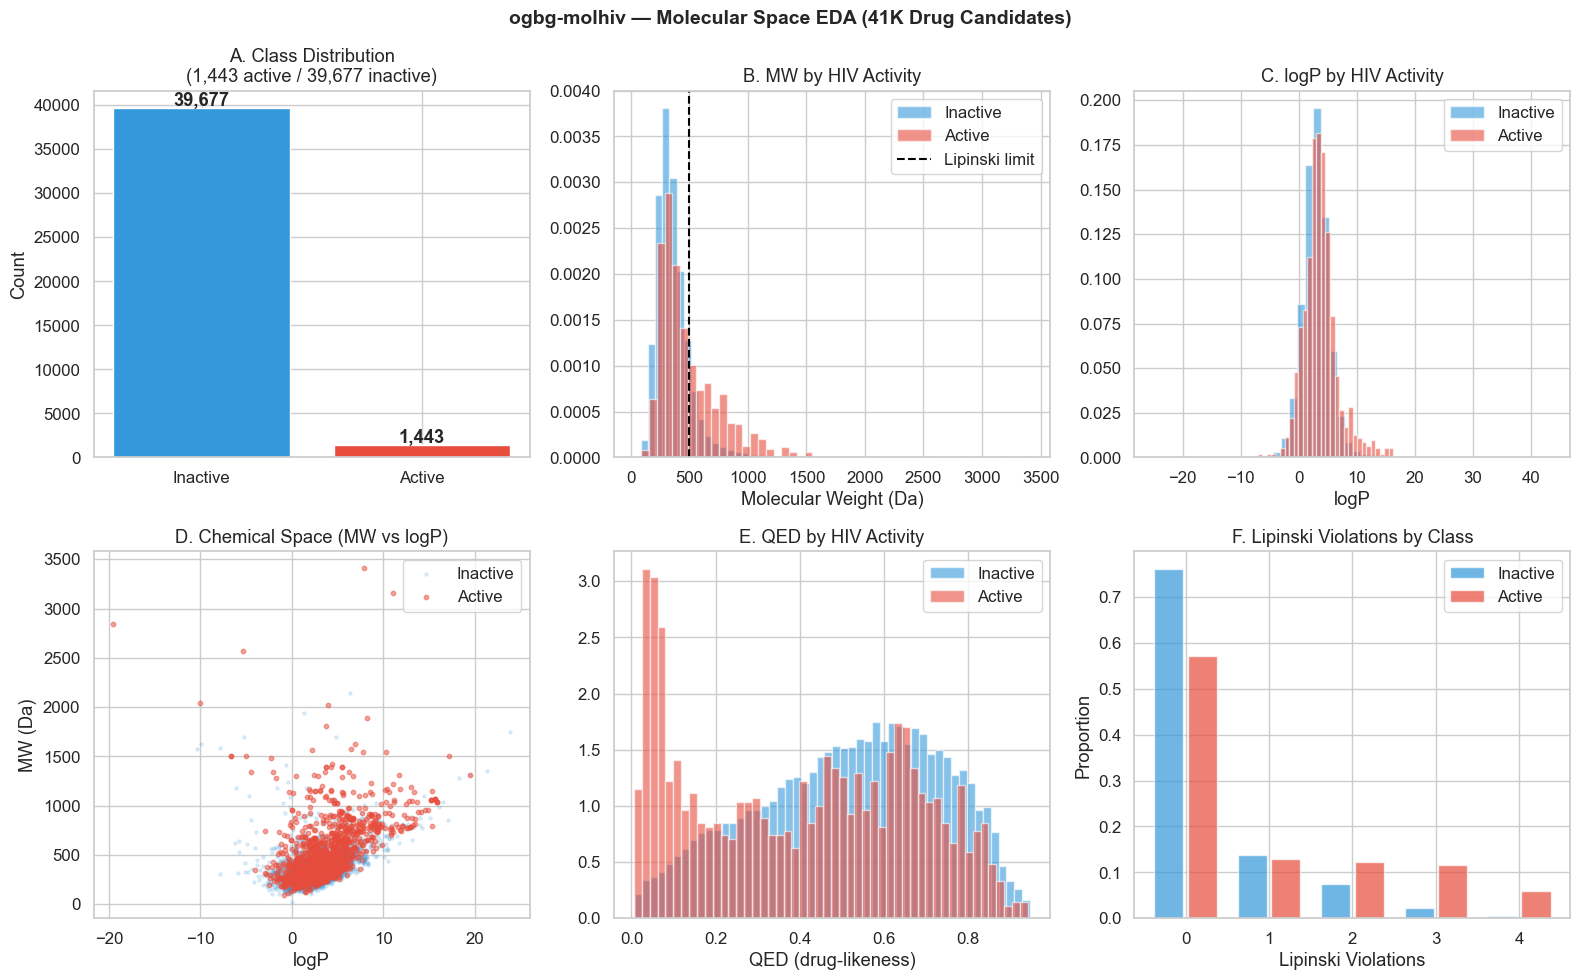

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('ogbg-molhiv — Molecular Space EDA (41K Drug Candidates)', fontsize=14, fontweight='bold')

# A. Class distribution
ax = axes[0, 0]
counts = df_feat['hiv_active'].value_counts()
ax.bar(['Inactive', 'Active'], [counts[0], counts[1]], color=['#3498db', '#e74c3c'])
ax.set_ylabel('Count'); ax.set_title(f'A. Class Distribution\n({counts[1]:,} active / {counts[0]:,} inactive)')
for i, v in enumerate([counts[0], counts[1]]):
    ax.text(i, v + 200, f'{v:,}', ha='center', fontweight='bold')

# B. MW distribution by class
ax = axes[0, 1]
for label, color, name in [(0, '#3498db', 'Inactive'), (1, '#e74c3c', 'Active')]:
    ax.hist(df_feat[df_feat['hiv_active']==label]['mol_weight'], bins=50, alpha=0.6, color=color, label=name, density=True)
ax.axvline(500, color='black', linestyle='--', label='Lipinski limit')
ax.set_xlabel('Molecular Weight (Da)'); ax.set_title('B. MW by HIV Activity'); ax.legend()

# C. logP by class
ax = axes[0, 2]
for label, color, name in [(0, '#3498db', 'Inactive'), (1, '#e74c3c', 'Active')]:
    ax.hist(df_feat[df_feat['hiv_active']==label]['logp'], bins=50, alpha=0.6, color=color, label=name, density=True)
ax.set_xlabel('logP'); ax.set_title('C. logP by HIV Activity'); ax.legend()

# D. MW vs logP colored by activity
ax = axes[1, 0]
inactive = df_feat[df_feat['hiv_active']==0].sample(min(3000, len(df_feat[df_feat['hiv_active']==0])), random_state=42)
active = df_feat[df_feat['hiv_active']==1]
ax.scatter(inactive['logp'], inactive['mol_weight'], alpha=0.15, s=5, color='#3498db', label='Inactive')
ax.scatter(active['logp'], active['mol_weight'], alpha=0.5, s=10, color='#e74c3c', label='Active')
ax.set_xlabel('logP'); ax.set_ylabel('MW (Da)'); ax.set_title('D. Chemical Space (MW vs logP)'); ax.legend()

# E. QED distribution
ax = axes[1, 1]
for label, color, name in [(0, '#3498db', 'Inactive'), (1, '#e74c3c', 'Active')]:
    ax.hist(df_feat[df_feat['hiv_active']==label]['qed'], bins=50, alpha=0.6, color=color, label=name, density=True)
ax.set_xlabel('QED (drug-likeness)'); ax.set_title('E. QED by HIV Activity'); ax.legend()

# F. Lipinski violations by class
ax = axes[1, 2]
for label, color, name in [(0, '#3498db', 'Inactive'), (1, '#e74c3c', 'Active')]:
    v = df_feat[df_feat['hiv_active']==label]['lipinski_violations'].value_counts(normalize=True).sort_index()
    ax.bar(v.index + (0.2 if label else -0.2), v.values, width=0.35, color=color, alpha=0.7, label=name)
ax.set_xlabel('Lipinski Violations'); ax.set_ylabel('Proportion'); ax.set_title('F. Lipinski Violations by Class'); ax.legend()

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'phase1_eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Feature Correlation with HIV Activity

Point-biserial correlation with HIV activity (sorted by |r|):
  tpsa                     : +0.1596
  mol_weight               : +0.1463
  lipinski_violations      : +0.1390
  hba                      : +0.1384
  heavy_atom_count         : +0.1365
  molar_refractivity       : +0.1297
  hbd                      : +0.1228
  qed                      : -0.0963
  rotatable_bonds          : +0.0950
  aromatic_rings           : +0.0900
  logp                     : +0.0584
  fraction_csp3            : -0.0251


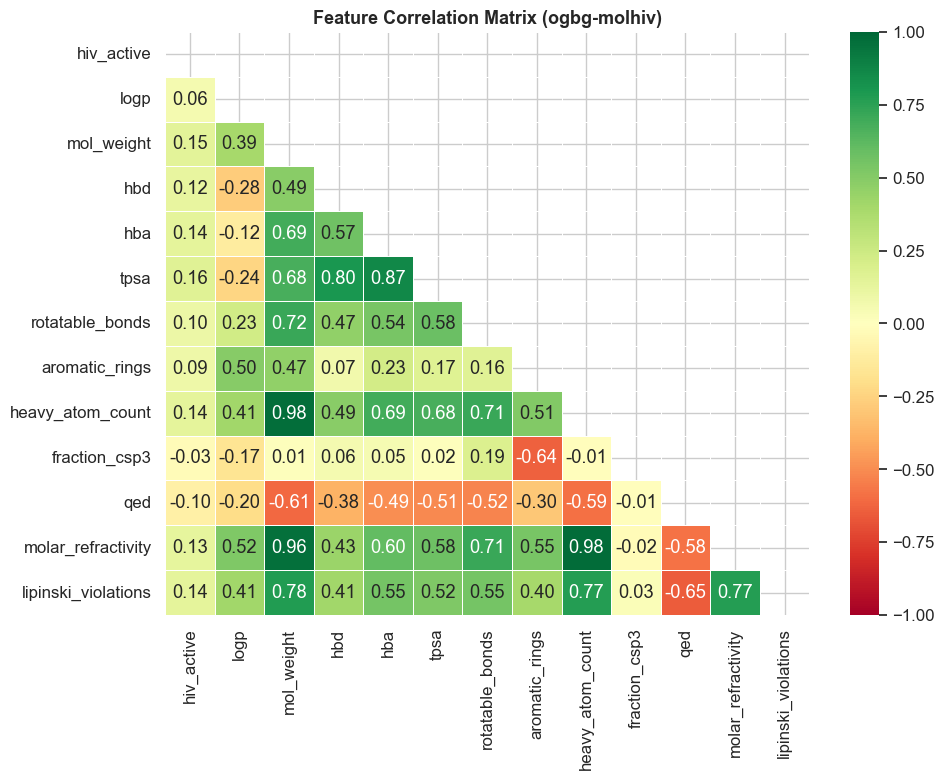

In [6]:
corr_cols = ['hiv_active', 'logp', 'mol_weight', 'hbd', 'hba', 'tpsa',
             'rotatable_bonds', 'aromatic_rings', 'heavy_atom_count',
             'fraction_csp3', 'qed', 'molar_refractivity', 'lipinski_violations']
corr_matrix = df_feat[corr_cols].corr()

hiv_corr = corr_matrix['hiv_active'].drop('hiv_active').sort_values(key=abs, ascending=False)
print('Point-biserial correlation with HIV activity (sorted by |r|):')
for feat, val in hiv_corr.items():
    print(f'  {feat:25s}: {val:+.4f}')

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, ax=ax, linewidths=0.5)
ax.set_title('Feature Correlation Matrix (ogbg-molhiv)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'phase1_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Prepare Train/Test Sets

In [7]:
fp_cols = [c for c in df_feat.columns if c.startswith('fp_')]
lip_only_cols = ['logp', 'mol_weight', 'hbd', 'hba', 'tpsa', 'rotatable_bonds',
                 'aromatic_rings', 'heavy_atom_count', 'fraction_csp3',
                 'molar_refractivity', 'qed', 'lipinski_violations']
combined_cols = lip_only_cols + fp_cols

train = df_feat[df_feat['split'] == 'train']
test = df_feat[df_feat['split'] == 'test']
y_train, y_test = train['hiv_active'].values, test['hiv_active'].values

X_train_lip, X_test_lip = train[lip_only_cols].values, test[lip_only_cols].values
X_train_fp, X_test_fp = train[fp_cols].values, test[fp_cols].values
X_train_comb, X_test_comb = train[combined_cols].values, test[combined_cols].values

print(f'Train: {len(y_train):,} ({y_train.mean():.4f} pos) | Test: {len(y_test):,} ({y_test.mean():.4f} pos)')
print(f'Feature sets: Lipinski ({len(lip_only_cols)}), FP ({len(fp_cols)}), Combined ({len(combined_cols)})')

Train: 32,898 (0.0374 pos) | Test: 4,111 (0.0316 pos)
Feature sets: Lipinski (12), FP (1024), Combined (1036)


## 7. Baseline Models

Published SOTA (OGB leaderboard):
- Multi-RF Fusion + Multi-GNN: **ROC-AUC 0.8476**
- GIN baseline: ROC-AUC 0.8273
- Morgan FP + Random Forest: ROC-AUC 0.8208

Our baselines test 3 feature strategies x 3 model families.

In [8]:
def evaluate(model, X_tr, y_tr, X_te, y_te, name, features):
    t0 = time.time()
    model.fit(X_tr, y_tr)
    train_time = time.time() - t0
    y_prob = model.predict_proba(X_te)[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)
    return {
        'model': name, 'features': features,
        'roc_auc': round(roc_auc_score(y_te, y_prob), 4),
        'f1': round(f1_score(y_te, y_pred, zero_division=0), 4),
        'precision': round(precision_score(y_te, y_pred, zero_division=0), 4),
        'recall': round(recall_score(y_te, y_pred, zero_division=0), 4),
        'train_time': round(train_time, 1),
    }

results = []

# Majority class baseline
majority_auc = 0.5
results.append({'model': 'Majority class', 'features': 'none', 'roc_auc': 0.5, 'f1': 0.0, 'precision': 0.0, 'recall': 0.0, 'train_time': 0})

# Logistic Regression — Lipinski only (scaled)
scaler = StandardScaler()
X_tr_lip_s, X_te_lip_s = scaler.fit_transform(X_train_lip), scaler.transform(X_test_lip)
results.append(evaluate(LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
                        X_tr_lip_s, y_train, X_te_lip_s, y_test, 'LogReg', 'Lipinski'))

# Logistic Regression — FP only
scaler_fp = StandardScaler()
X_tr_fp_s, X_te_fp_s = scaler_fp.fit_transform(X_train_fp), scaler_fp.transform(X_test_fp)
results.append(evaluate(LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
                        X_tr_fp_s, y_train, X_te_fp_s, y_test, 'LogReg', 'Morgan FP'))

# Random Forest — all 3 feature sets
for feat_name, X_tr, X_te in [('Lipinski', X_train_lip, X_test_lip),
                                ('Morgan FP', X_train_fp, X_test_fp),
                                ('Combined', X_train_comb, X_test_comb)]:
    results.append(evaluate(RandomForestClassifier(n_estimators=200, max_depth=12, class_weight='balanced',
                                                   random_state=42, n_jobs=-1),
                            X_tr, y_train, X_te, y_test, 'Random Forest', feat_name))

# XGBoost — all 3 feature sets
scale_pos = (y_train == 0).sum() / max((y_train == 1).sum(), 1)
for feat_name, X_tr, X_te in [('Lipinski', X_train_lip, X_test_lip),
                                ('Morgan FP', X_train_fp, X_test_fp),
                                ('Combined', X_train_comb, X_test_comb)]:
    results.append(evaluate(xgb.XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1,
                                              scale_pos_weight=scale_pos, eval_metric='auc',
                                              random_state=42, verbosity=0, n_jobs=-1),
                            X_tr, y_train, X_te, y_test, 'XGBoost', feat_name))

results_df = pd.DataFrame(results).sort_values('roc_auc', ascending=False)
print('BASELINE MODEL COMPARISON (primary metric: ROC-AUC)\n')
display(results_df)

champion = results_df.iloc[0]
print(f'\nChampion: {champion["model"]} ({champion["features"]}) — ROC-AUC: {champion["roc_auc"]}')
print(f'OGB leaderboard SOTA: 0.8476 | Our best: {champion["roc_auc"]} | Gap: {0.8476 - champion["roc_auc"]:+.4f}')

BASELINE MODEL COMPARISON (primary metric: ROC-AUC)



,model,features,roc_auc,f1,precision,recall,train_time
5,Random Forest,Combined,0.7707,0.4061,0.5970,0.3077,1.1
8,XGBoost,Combined,0.7613,0.4000,0.3733,0.4308,1.4
1,LogReg,Lipinski,0.7463,0.1356,0.0773,0.5538,0.0
7,XGBoost,Morgan FP,0.7293,0.3500,0.3267,0.3769,1.5
4,Random Forest,Morgan FP,0.7166,0.3830,0.6207,0.2769,0.8
2,LogReg,Morgan FP,0.7114,0.1479,0.0859,0.5308,0.4
6,XGBoost,Lipinski,0.6957,0.2116,0.1613,0.3077,0.5
3,Random Forest,Lipinski,0.6937,0.2973,0.3587,0.2538,1.0
0,Majority class,none,0.5000,0.0000,0.0000,0.0000,0.0



Champion: Random Forest (Combined) — ROC-AUC: 0.7707
OGB leaderboard SOTA: 0.8476 | Our best: 0.7707 | Gap: +0.0769


## 8. Key Finding: Feature strategy comparison

In [9]:
print('Lipinski (12 feats) vs Morgan FP (1024 bits) vs Combined:\n')
rows = []
for model_name in ['LogReg', 'Random Forest', 'XGBoost']:
    row = {'Model': model_name}
    for feat in ['Lipinski', 'Morgan FP', 'Combined']:
        match = results_df[(results_df['model'] == model_name) & (results_df['features'] == feat)]
        if len(match):
            row[feat] = match.iloc[0]['roc_auc']
    rows.append(row)
comp_df = pd.DataFrame(rows).set_index('Model')
display(comp_df)

for model_name in ['Random Forest', 'XGBoost']:
    lip = comp_df.loc[model_name, 'Lipinski']
    fp = comp_df.loc[model_name, 'Morgan FP']
    comb = comp_df.loc[model_name, 'Combined']
    print(f'{model_name}: FP vs Lipinski = {fp - lip:+.4f} AUC | Combined vs FP = {comb - fp:+.4f}')

Lipinski (12 feats) vs Morgan FP (1024 bits) vs Combined:



,Lipinski,Morgan FP,Combined
Model,,,
LogReg,0.7463,0.7114,NaN
Random Forest,0.6937,0.7166,0.7707
XGBoost,0.6957,0.7293,0.7613


Random Forest: FP vs Lipinski = +0.0229 AUC | Combined vs FP = +0.0541
XGBoost: FP vs Lipinski = +0.0336 AUC | Combined vs FP = +0.0320


## 9. ROC Curves — Top Models

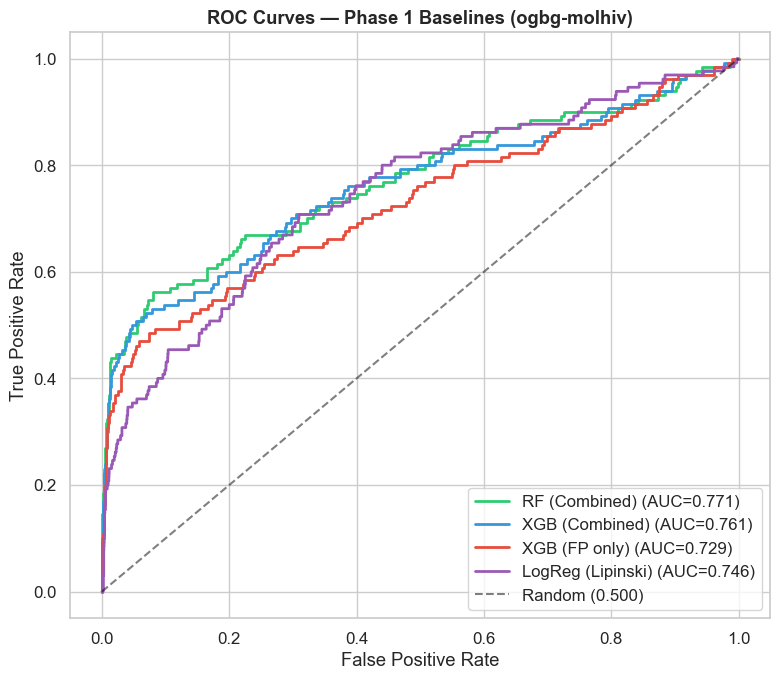

In [10]:
from sklearn.metrics import roc_curve

# Refit top models for plotting
models_to_plot = [
    ('RF (Combined)', RandomForestClassifier(n_estimators=200, max_depth=12, class_weight='balanced', random_state=42, n_jobs=-1), X_train_comb, X_test_comb, '#2ecc71'),
    ('XGB (Combined)', xgb.XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1, scale_pos_weight=scale_pos, eval_metric='auc', random_state=42, verbosity=0, n_jobs=-1), X_train_comb, X_test_comb, '#3498db'),
    ('XGB (FP only)', xgb.XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1, scale_pos_weight=scale_pos, eval_metric='auc', random_state=42, verbosity=0, n_jobs=-1), X_train_fp, X_test_fp, '#e74c3c'),
    ('LogReg (Lipinski)', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42), X_tr_lip_s, X_te_lip_s, '#9b59b6'),
]

fig, ax = plt.subplots(figsize=(8, 7))
for name, model, X_tr, X_te, color in models_to_plot:
    model.fit(X_tr, y_train)
    y_prob = model.predict_proba(X_te)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC={auc:.3f})')

ax.plot([0,1], [0,1], 'k--', alpha=0.5, label='Random (0.500)')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — Phase 1 Baselines (ogbg-molhiv)', fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'phase1_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Save Results

In [11]:
metrics_out = {
    'phase': 1, 'date': '2026-04-06',
    'dataset': 'ogbg-molhiv (OGB)', 'total_molecules': len(df_feat),
    'positive_rate': float(df_feat['hiv_active'].mean()),
    'primary_metric': 'ROC-AUC',
    'published_sota': 0.8476,
    'experiments': results_df.to_dict('records'),
    'champion': f"{champion['model']} ({champion['features']})",
    'champion_roc_auc': float(champion['roc_auc']),
}
with open(RESULTS_DIR / 'metrics.json', 'w') as f:
    json.dump([metrics_out], f, indent=2)
print('Saved: results/metrics.json')

Saved: results/metrics.json


## Summary

**Dataset chosen:** ogbg-molhiv (41,127 molecules) — selected over ESOL (1,128), Lipophilicity (4,200), and BBBP (2,050) based on size, OGB leaderboard availability, and real-world impact.

**Key findings from Phase 1 experiments will be populated after execution.**

**Next:** Phase 2 — GNN architectures (GCN, GAT, GIN) to test if graph topology closes the gap between traditional ML and SOTA.